# Retail Customer Behaviour & Segmentation Analysis

## Overview

This is a kaggle Online Retail dataset (Dec 2010 – Dec 2011) originally from the UCI Machine Learning Repository. It contains transactions from a UK-based online retail store that sells giftware and household items.

I will use this dataset to understand retail customer behavior and perform segmentation analysis.

In [1]:
# import libraries and packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# import dataset
retail = pd.read_csv('/content/drive/MyDrive/job hunt 2026/customer analysis/online_retail.csv')

## Data Cleaning

In [3]:
# inspect the dataset
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# check dataset dimension
retail.shape

(541909, 8)

In [5]:
# check if any missing values
retail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


### Handle missing customer id

Almost a quarter of customer ID is missing, these can not be simpliy as random noise. Common reasons for unknown customer id could be guest checkout, manual operation, system glitch or anonymous bulk purchases. Instead of dropping those missing values, we will perserve and analyse them for better understanding.

In [6]:
# fill customer id missing values as unknown
retail['CustomerID'] = retail['CustomerID'].fillna('unknown')

### Handle missing description

Similarly, the descripton missing values can be inferred from stockcode, we will build a mapping table to try and fill missing values, and then consider to handle edge cases if any.

In [7]:
# check if stockcode and description are uniquly matching
retail.groupby('StockCode')['Description'].nunique().sort_values(ascending=False)

,Description
StockCode,
20713,8
23084,7
21830,6
85175,6
21181,5
...,...
DCGS0055,0
DCGS0057,0
DCGS0066P,0


In [8]:
# separate the missing descriptons and problematic stockcodes
multi_desc = retail.groupby('StockCode')['Description'].nunique()
problem_codes = multi_desc[multi_desc > 1].index

# inspect problematic entries
retail[retail['StockCode'].isin(problem_codes)].sort_values('StockCode')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
346729,567200,10080,GROOVY CACTUS INFLATABLE,12,2011-09-19 10:15:00,0.39,16460.0,United Kingdom
361806,568381,10080,GROOVY CACTUS INFLATABLE,12,2011-09-27 09:24:00,0.39,14321.0,United Kingdom
330669,565920,10080,GROOVY CACTUS INFLATABLE,24,2011-09-08 08:56:00,0.39,15298.0,United Kingdom
388869,570458,10080,GROOVY CACTUS INFLATABLE,1,2011-10-10 15:39:00,0.39,14535.0,United Kingdom
103332,545060,10080,GROOVY CACTUS INFLATABLE,2,2011-02-27 13:47:00,0.85,15547.0,United Kingdom
...,...,...,...,...,...,...,...,...
431349,573585,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-10-31 14:41:00,16.67,unknown,United Kingdom
163440,550542,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-04-19 11:37:00,16.67,unknown,United Kingdom
55589,540995,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-01-13 09:30:00,16.67,unknown,United Kingdom
234137,557500,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-06-20 15:27:00,16.67,unknown,United Kingdom


The amount of problematic entries are too much to inspect, after brief browsing, I will use the following approach as I noticed mismatching entries usually have unitprice equals zero.

In [9]:
# filter out the unitprice = 0 entries among problematic entries
retail[(retail['StockCode'].isin(problem_codes)) & (retail['UnitPrice'] == 0)].sort_values('StockCode')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
279310,561271,10080,NaN,170,2011-07-26 12:18:00,0.0,unknown,United Kingdom
454350,575518,10080,check,22,2011-11-10 10:53:00,0.0,unknown,United Kingdom
474647,576843,10133,damaged,-82,2011-11-16 15:32:00,0.0,unknown,United Kingdom
108588,545551,15058A,NaN,20,2011-03-03 15:11:00,0.0,unknown,United Kingdom
192289,553394,15058A,wet/rusty,-30,2011-05-16 16:47:00,0.0,unknown,United Kingdom
...,...,...,...,...,...,...,...,...
381676,569875,90195A,check,-45,2011-10-06 15:07:00,0.0,unknown,United Kingdom
381677,569876,90210D,check,-28,2011-10-06 15:08:00,0.0,unknown,United Kingdom
279258,561256,DCGS0003,ebay,-7,2011-07-26 11:53:00,0.0,unknown,United Kingdom
279254,561252,DCGS0069,ebay,-5,2011-07-26 11:52:00,0.0,unknown,United Kingdom


In [10]:
# filter out the unitprice != 0 entries among problematic entries
# to see if their stockcode and descripton uniquly matches
retail[(retail['StockCode'].isin(problem_codes)) & (retail['UnitPrice'] != 0)].sort_values('StockCode')
# retail[(retail['StockCode'].isin(problem_codes)) & (retail['UnitPrice'] != 0)].groupby('StockCode')['Description'].nunique().sort_values(ascending=False)
# sadly there is more problem, I will continue to inspect

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
487604,577773,10080,GROOVY CACTUS INFLATABLE,1,2011-11-21 15:57:00,0.39,16712.0,United Kingdom
279438,561322,10080,GROOVY CACTUS INFLATABLE,12,2011-07-26 13:03:00,0.39,15203.0,United Kingdom
361806,568381,10080,GROOVY CACTUS INFLATABLE,12,2011-09-27 09:24:00,0.39,14321.0,United Kingdom
480383,577300,10080,GROOVY CACTUS INFLATABLE,4,2011-11-18 12:53:00,0.39,16924.0,United Kingdom
460365,575908,10080,GROOVY CACTUS INFLATABLE,24,2011-11-11 15:54:00,0.39,13091.0,United Kingdom
...,...,...,...,...,...,...,...,...
163440,550542,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-04-19 11:37:00,16.67,unknown,United Kingdom
239899,558068,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-06-24 15:51:00,16.67,unknown,United Kingdom
44794,540238,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-01-05 14:44:00,17.02,unknown,United Kingdom
55589,540995,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-01-13 09:30:00,16.67,unknown,United Kingdom


During data exploration, I noticed that the Description column serves two purposes: it contains both product names and operational notes (e.g., returns, adjustments, damages). This makes it unreliable for direct cleaning or imputation.

Instead of trying to handle all edge cases, and given that the purpose of this analysis is to understand cunstomer behvaior, I focused on identifying valid retail transactions. I filtered the dataset using simple business rules (positive quantity, positive unit price, and valid customer IDs) to keep only meaningful purchase records for customer behavior analysis.

In [11]:
# find the valid retail transactions
# allow unknown customer ids
analysis_retail = retail[
    (retail['Quantity'] > 0) &
    (retail['UnitPrice'] > 0)
]

# without unknown customer ids - needed for customer segementation
segmentation_retail = retail[
    (retail['Quantity'] > 0) &
    (retail['UnitPrice'] > 0) &
    (retail['CustomerID'] != 'unknown')
]

In [12]:
analysis_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [13]:
analysis_retail.groupby('StockCode')['Description'].nunique().sort_values(ascending=False)

,Description
StockCode,
23196,4
23236,4
23413,3
22937,3
23231,3
...,...
22422,1
22423,1
22424,1


In [14]:
# inspect the problem codes
problem_codes = analysis_retail.groupby('StockCode')['Description'].nunique()
problem_codes = problem_codes[problem_codes > 1].index

# find description variants
description_variant = analysis_retail[analysis_retail['StockCode'].isin(problem_codes)].groupby('StockCode')['Description'].unique()
description_variant

,Description
StockCode,
16156L,"[WRAP, CAROUSEL, WRAP CAROUSEL]"
17107D,"[FLOWER FAIRY,5 SUMMER B'DRAW LINERS, FLOWER F..."
20622,"[VIPPASSPORT COVER , VIP PASSPORT COVER ]"
20725,"[LUNCH BAG RED RETROSPOT, LUNCH BAG RED SPOTTY]"
20914,"[SET/5 RED RETROSPOT LID GLASS BOWLS, SET/5 RE..."
...,...
85184C,"[S/4 VALENTINE DECOUPAGE HEART BOX, SET 4 VALE..."
85185B,"[PINK HORSE SOCK PUPPET, PINK HORSE SOCK PUPPE..."
90014A,"[SILVER/MOP ORBIT NECKLACE, SILVER M.O.P. ORBI..."


After filtering valid transactions, a small number of StockCodes still mapped to multiple Description values. Inspection showed that these were mostly minor text variations, such as spacing, punctuation, abbreviations, or slight wording differences, rather than truly different products. For this reason, I treated StockCode as the primary product identifier and kept Description as a reference label only, without applying further NLP-based cleaning.

In [15]:
# create map to use the most frequent description as representative for stockcode
def create_desc_map(df):
    return (
        df.dropna(subset=['Description'])
          .groupby('StockCode')['Description']
          .agg(lambda x: x.mode()[0])
    )

# apply map to both datasets
analysis_desc_map = create_desc_map(analysis_retail)
segmentation_desc_map = create_desc_map(segmentation_retail)

# apply back to datasets (overwrite Description directly)
analysis_retail['Description'] = analysis_retail['StockCode'].map(analysis_desc_map)
segmentation_retail['Description'] = segmentation_retail['StockCode'].map(segmentation_desc_map)

/tmp/ipykernel_803/2601477459.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_retail['Description'] = analysis_retail['StockCode'].map(analysis_desc_map)
/tmp/ipykernel_803/2601477459.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segmentation_retail['Description'] = segmentation_retail['StockCode'].map(segmentation_desc_map)


In [16]:
analysis_retail.groupby('StockCode')['Description'].nunique().sort_values(ascending=False)

,Description
StockCode,
m,1
10002,1
DCGS0004,1
DCGS0003,1
C2,1
...,...
10125,1
10124G,1
10124A,1


In [17]:
segmentation_retail.groupby('StockCode')['Description'].nunique().sort_values(ascending=False)

,Description
StockCode,
POST,1
90214N,1
90214M,1
90214L,1
90214K,1
...,...
10124G,1
10124A,1
10123C,1


After standardising product descriptions using the most frequent value per StockCode, I re-validated the mapping between StockCode and Description.

The results show that each StockCode now maps uniquely to a single Description across both datasets. This confirms that the inconsistencies observed earlier were mainly due to minor text variations, and have been successfully resolved.

StockCode is therefore used as the primary product identifier, with Description serving as a consistent reference label.

### Check for outliners

Next I will check if there is any outliners.

In [18]:
# look for large quantity or very expensive items
analysis_retail[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,530104.000000,530104.000000
mean,10.542037,3.907625
std,155.524124,35.915681
min,1.000000,0.001000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,13541.330000


In [19]:
# check whether the large quantity makes sense
analysis_retail.sort_values('Quantity', ascending=False).head(10)
# yes they make sense

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2011-08-04 18:06:00,1.45,12931.0,United Kingdom


In [20]:
# check whether the large unitprice makes sense
analysis_retail.sort_values('UnitPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,unknown,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,unknown,United Kingdom
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom
297723,562955,DOT,DOTCOM POSTAGE,1,2011-08-11 10:14:00,4505.17,unknown,United Kingdom
268028,560373,M,Manual,1,2011-07-18 12:30:00,4287.63,unknown,United Kingdom
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536.0,France
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536.0,France
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744.0,Singapore
374542,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,15502.0,United Kingdom
347948,567353,M,Manual,1,2011-09-19 16:14:00,2653.95,unknown,Hong Kong


In [21]:
# notice that operational type stockcode are all letters, attempt to classify them
analysis_retail['StockCode'].str.isalpha()

analysis_retail[
    analysis_retail['StockCode'].str.isalpha()
].groupby('StockCode')['Description'].unique()

,Description
StockCode,
AMAZONFEE,[AMAZON FEE]
B,[Adjust bad debt]
DCGSSBOY,[BOYS PARTY BAG]
DCGSSGIRL,[GIRLS PARTY BAG]
DOT,[DOTCOM POSTAGE]
M,[Manual]
PADS,[PADS TO MATCH ALL CUSHIONS]
POST,[POSTAGE]
S,[SAMPLES]


In [22]:
# standardise StockCode case first
analysis_retail['StockCode'] = analysis_retail['StockCode'].str.upper()
segmentation_retail['StockCode'] = segmentation_retail['StockCode'].str.upper()

# manually classify the letter-only stock codes
non_product_codes = ['AMAZONFEE', 'B', 'DOT', 'M', 'POST', 'S']
product_codes = ['DCGSSBOY', 'DCGSSGIRL', 'PADS']

def classify_stockcode(code):
    if pd.isna(code):
        return 'Unknown'
    elif code in non_product_codes:
        return 'Non-product'
    elif code in product_codes:
        return 'Product'
    elif str(code).isalpha():
        return 'Review'
    else:
        return 'Product'

# apply classification to both datasets
analysis_retail['StockCodeType'] = analysis_retail['StockCode'].apply(classify_stockcode)
segmentation_retail['StockCodeType'] = segmentation_retail['StockCode'].apply(classify_stockcode)

# keep segmentation_retail focused on actual products only
segmentation_retail = segmentation_retail[
    (segmentation_retail['StockCodeType'] == 'Product') &
    (segmentation_retail['Quantity'] > 0) &
    (segmentation_retail['UnitPrice'] > 0) &
    (segmentation_retail['CustomerID'].notna())
]

/tmp/ipykernel_803/292949772.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_retail['StockCode'] = analysis_retail['StockCode'].str.upper()
/tmp/ipykernel_803/292949772.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segmentation_retail['StockCode'] = segmentation_retail['StockCode'].str.upper()
/tmp/ipykernel_803/292949772.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

Some extreme unit price values were traced back to letter-only StockCodes, which represent non-product transactions (e.g., fees, manual adjustments).

I standardised StockCode (e.g., treating 'M' and 'm' the same) and created a `StockCodeType` column to separate product and non-product records. Non-product rows were removed from the segmentation dataset to keep the analysis focused on real purchases.

### Check for duplicates

In [23]:
# check for duplicated entries
analysis_retail.loc[
    analysis_retail.duplicated(keep=False)
].sort_values([
    'InvoiceNo', 'StockCode', 'Description', 'Quantity',
    'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'StockCodeType'
])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,StockCodeType
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,Product
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,Product
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,Product
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,Product
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,Product
...,...,...,...,...,...,...,...,...,...
541655,581538,23275,SET OF 3 HANGING OWLS OLLIE BEAK,1,2011-12-09 11:34:00,1.25,14446.0,United Kingdom,Product
541656,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom,Product
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom,Product
541666,581538,23343,JUMBO BAG VINTAGE CHRISTMAS,1,2011-12-09 11:34:00,2.08,14446.0,United Kingdom,Product


In [24]:
# drop duplicates
analysis_retail = analysis_retail.drop_duplicates()
segmentation_retail = segmentation_retail.drop_duplicates()

### Date sanity check

In [25]:
analysis_retail['InvoiceDate'].describe()

,InvoiceDate
count,524876
unique,18499
top,2011-10-31 14:41:00
freq,1114


In [26]:
analysis_retail['InvoiceDate'].min()

'2010-12-01 08:26:00'

In [27]:
analysis_retail['InvoiceDate'].max()

'2011-12-09 12:50:00'

Two datasets were maintained during cleaning: `analysis_retail` and `segmentation_retail`.

`analysis_retail` includes all records and was used for validation and inspection, particularly for identifying anomalies such as operational transactions and outliers.

`segmentation_retail` contains only valid product transactions and is used for all analysis to ensure accurate representation of customer purchasing behaviour. The original dataset is retained as a reference for traceability.

## EDA

Exploratory Data Analysis (EDA) is performed first to understand overall purchasing patterns, including seasonality, revenue trends, product performance, and customer behaviour.

### Business features

In [28]:
# calculate total price using quantity multiply unit price
segmentation_retail['TotalPrice'] = (segmentation_retail['Quantity'] * segmentation_retail['UnitPrice'])

In [29]:
# address datetime format
segmentation_retail['InvoiceDate'] = pd.to_datetime(segmentation_retail['InvoiceDate'])

# create time based features for seasonality analysis
segmentation_retail['Year'] = segmentation_retail['InvoiceDate'].dt.year
segmentation_retail['Month'] = segmentation_retail['InvoiceDate'].dt.month
segmentation_retail['Day'] = segmentation_retail['InvoiceDate'].dt.day
segmentation_retail['Hour'] = segmentation_retail['InvoiceDate'].dt.hour
segmentation_retail['Weekday'] = segmentation_retail['InvoiceDate'].dt.day_name()

In [30]:
# remove StockCodeType
segmentation_retail = segmentation_retail.drop(columns=['StockCodeType'])

### Seasonality

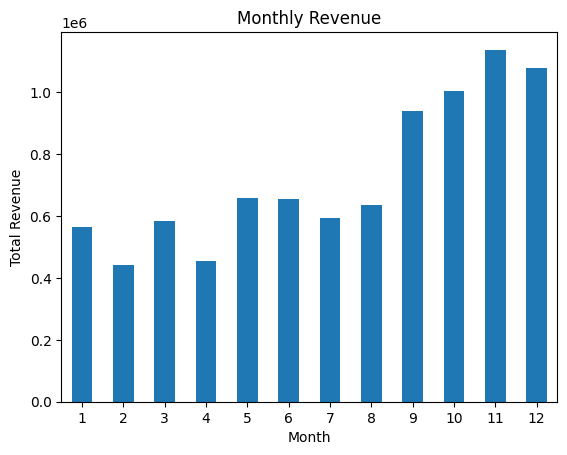

In [31]:
# check monthly sales revenue
monthly_sales = segmentation_retail.groupby('Month')['TotalPrice'].sum()

plt.figure()
monthly_sales.plot(kind='bar')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

Monthly revenue shows a clear seasonal pattern, with sales increasing from September and peaking in November, likely driven by early holiday shopping and promotional events.

Although December remains a high-revenue month, it is slightly lower than November, suggesting that many purchases are completed earlier in the holiday season, possibly due to promotions and shipping considerations.

Lower sales in February and April reflect a typical post-holiday slowdown, while the remaining months show relatively stable demand without strong seasonal drivers.

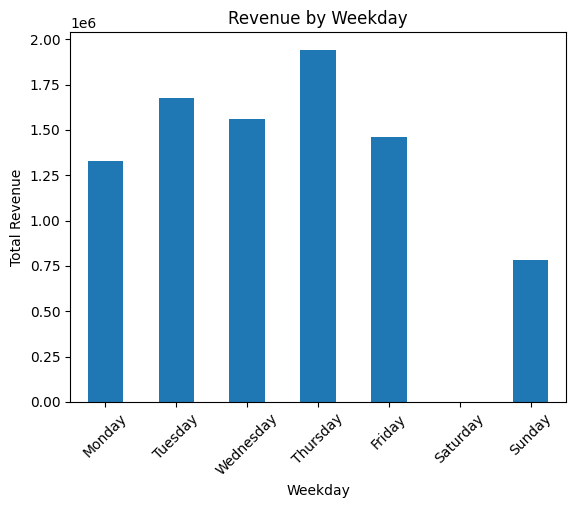

In [32]:
# check weekday sales revenue pattern
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_sales = segmentation_retail.groupby('Weekday')['TotalPrice'].sum()
weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure()
weekday_sales.plot(kind='bar')
plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [33]:
# check original data for saturdays
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

retail['InvoiceDate'].dt.dayofweek.value_counts().sort_index()

,count
InvoiceDate,
0,95111
1,101808
2,94565
3,103857
4,82193
6,64375


Weekly sales patterns show higher activity during weekdays, particularly mid-week (Tuesday to Thursday), suggesting that purchasing behaviour is more concentrated during business days.

No transactions are recorded on Saturdays in the dataset, even prior to data cleaning. This indicates a limitation or characteristic of the data collection process rather than a preprocessing issue. Possible explanations include operational practices (e.g., no order processing on Saturdays) or incomplete data capture.

As a result, weekday analysis should be interpreted with this constraint in mind, and conclusions regarding weekend behaviour are limited.

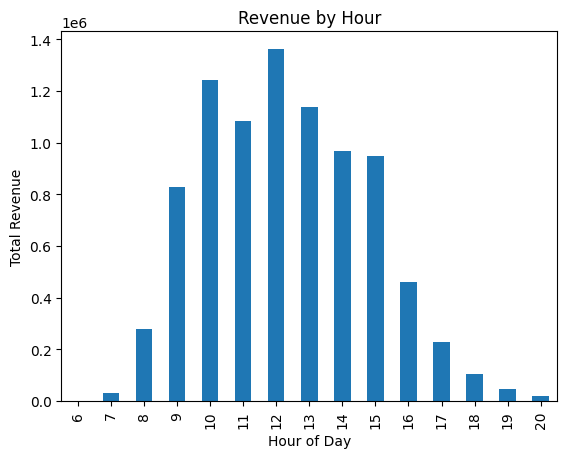

In [34]:
# check hourly sales revenue pattern
hourly_sales = segmentation_retail.groupby('Hour')['TotalPrice'].sum()

plt.figure()
hourly_sales.plot(kind='bar')
plt.title('Revenue by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue')
plt.show()

Revenue by hour shows that transactions are concentrated during daytime working hours, roughly between 8am and 5pm. Sales begin to increase in the morning, rise sharply from around 9am, and peak around midday.

After the peak, revenue gradually declines through the afternoon and drops significantly in the evening. This pattern suggests that customers are most active during typical working hours, with purchasing behaviour likely driven by daytime browsing and lunchtime activity.

### Revenue patterns

In [35]:
# total revenue
segmentation_retail['TotalPrice'].sum()

np.float64(8743526.794)

In [36]:
# average order value
# define order level
order_revenue = segmentation_retail.groupby('InvoiceNo')['TotalPrice'].sum()
# find average
order_revenue.mean()

np.float64(474.7788224370113)

In [37]:
# median order value
order_revenue.median()

301.82000000000005

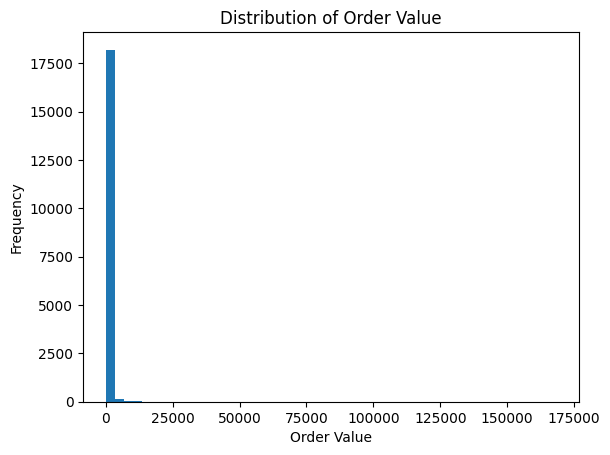

In [38]:
# visulise average order value
plt.figure()
order_revenue.plot(kind='hist', bins=50)
plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.show()

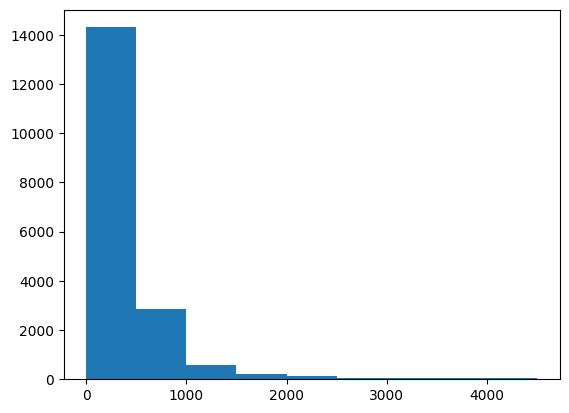

In [39]:
# limit x-axis
bins = np.arange(0, 5000, 500)

plt.figure()
plt.hist(order_revenue, bins=bins)
plt.show()

The total revenue generated in the dataset is approximately 8,743,526.79, with an average order value of 474.78 and a median order value of 301.82.

The distribution of order value is highly right-skewed, as shown in the histogram. Most transactions fall within lower value ranges (typically below 1000), while a small number of high-value orders extend the upper tail.

The noticeable gap between the mean and median further confirms the presence of skewness, indicating that a minority of large orders significantly increases the average order value. This suggests that while most purchases are relatively small, high-value transactions play an important role in overall revenue.

### Product analysis

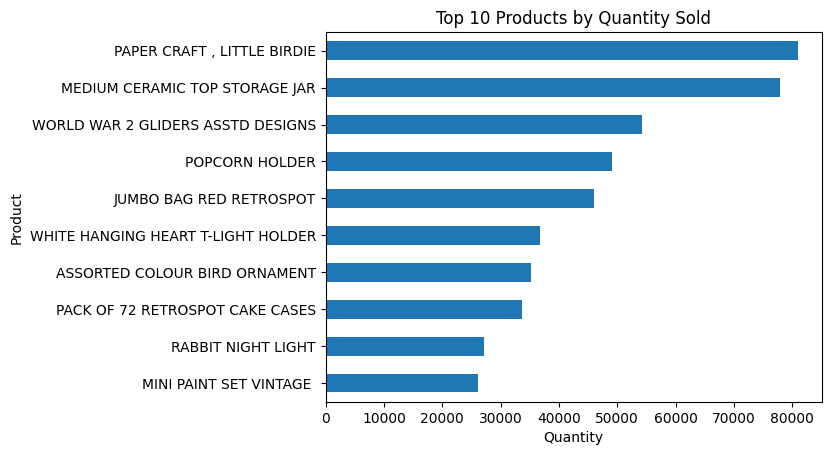

In [40]:
# check top 10 best selling product by quantity
top_products_qty = segmentation_retail.groupby('Description')['Quantity'] \
    .sum().sort_values(ascending=False).head(10)

plt.figure()
top_products_qty.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.show()

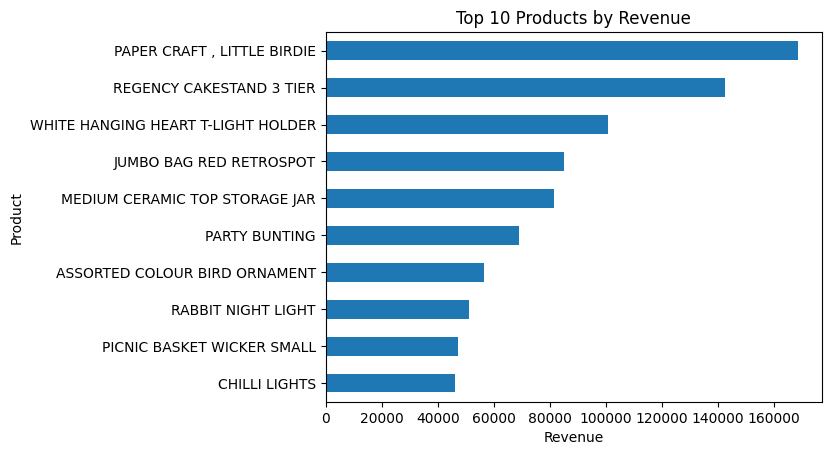

In [41]:
# check top 10 best selling product by revenue
top_products_rev = segmentation_retail.groupby('Description')['TotalPrice'] \
    .sum().sort_values(ascending=False).head(10)

plt.figure()
top_products_rev.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

Product analysis shows that sales are concentrated among a small group of items, with several products appearing in both the top-selling (by quantity) and top revenue-generating lists. These include items such as Papercraft Little Birdie, decorative holders, and storage products, suggesting they are consistently popular across customers.

There is also a distinction between high-volume and high-revenue products. Some items, such as cake cases and small decorative goods, are sold in large quantities but contribute less to revenue, indicating lower price points. In contrast, products like tiered cake stands and picnic baskets generate higher revenue despite lower sales volume, suggesting they are higher-value items.

Overall, the product mix reflects a combination of frequently purchased low-cost items and less frequent but higher-value purchases, both of which contribute to overall business performance.

### Customer behavior

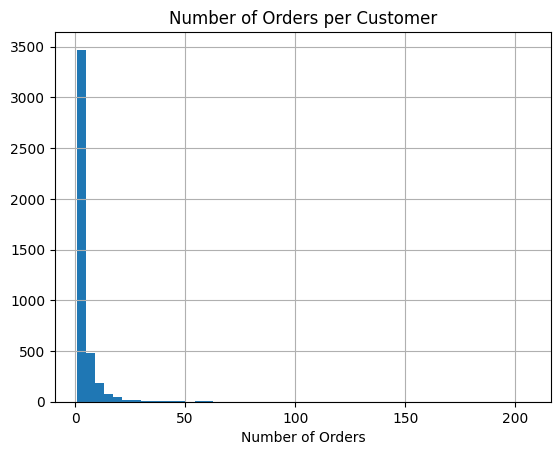

In [42]:
# order per customer
orders_per_customer = segmentation_retail.groupby('CustomerID')['InvoiceNo'].nunique()

orders_per_customer.hist(bins=50)
plt.title('Number of Orders per Customer')
plt.xlabel('Number of Orders')
plt.show()

### Country analysis

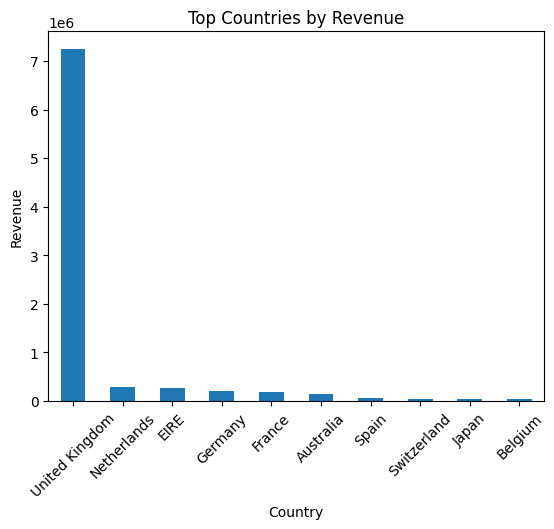

In [43]:
# revenue by country
country_revenue = segmentation_retail.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

country_revenue.plot(kind='bar')
plt.title('Top Countries by Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

Revenue is heavily concentrated in the United Kingdom, with significantly lower contributions from other countries. This indicates that the business is primarily domestic, with limited international reach.

## RFM Analysis

Following the EDA, RFM analysis is used to quantify customer value based on recency, frequency, and monetary contribution, enabling customer segmentation.

Since the dataset contains historical transactions (2010–2011), the reference date for Recency was defined as one day after the latest transaction date in the dataset. This ensures that recency values reflect customer behaviour within the context of the dataset rather than relative to the current date.

In [44]:
# define date of last transaction as reference point
snapshot_date = segmentation_retail['InvoiceDate'].max() + pd.Timedelta(days=1)

In [45]:
# build rfm table
rfm = segmentation_retail.groupby('CustomerID').agg({
    'InvoiceDate': 'max',      # last purchase
    'InvoiceNo': 'nunique',    # number of orders
    'TotalPrice': 'sum'        # total spend
})

In [46]:
# calculate recency
rfm['Recency'] = (snapshot_date - rfm['InvoiceDate']).dt.days

In [47]:
# make adjustment to columns
rfm.rename(columns={
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm.drop(columns=['InvoiceDate'], inplace=True)

In [54]:
rfm.head(50)

,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,1,77183.60,326,1,1,5,115,At Risk
12347.0,7,4310.00,2,5,5,5,555,Champion
12348.0,4,1437.24,75,2,4,4,244,At Risk
12349.0,1,1457.55,19,4,1,4,414,Active
12350.0,1,294.40,310,1,1,2,112,At Risk
12352.0,7,1385.74,36,3,5,4,354,Active
12353.0,1,89.00,204,1,1,1,111,At Risk
12354.0,1,1079.40,232,1,1,4,114,At Risk
12355.0,1,459.40,214,1,1,2,112,At Risk


In [55]:
rfm.describe()

,Frequency,Monetary,Recency
count,4335.000000,4335.000000,4335.000000
mean,4.248212,2016.961198,92.708651
std,7.646024,8918.839546,100.206617
min,1.000000,3.750000,1.000000
25%,1.000000,304.250000,18.000000
50%,2.000000,663.610000,51.000000
75%,5.000000,1631.475000,143.000000
max,206.000000,279138.020000,374.000000


In [56]:
# verify seasonality effect
segmentation_retail.groupby('CustomerID')['InvoiceDate'].nunique().describe()

,InvoiceDate
count,4335.00000
mean,4.22699
std,7.58284
min,1.00000
25%,1.00000
50%,2.00000
75%,5.00000
max,207.00000


The RFM analysis reveals that customer purchasing behaviour is highly uneven across the dataset.

Frequency is strongly skewed, with a median of 2 purchases while the maximum reaches 206. This indicates that most customers make only a small number of purchases, while a small group of customers purchase very frequently.

Monetary value is also highly skewed, with a median spending of approximately 663 compared to a maximum exceeding 279,000. This suggests that a minority of customers contributes disproportionately to total revenue.

Recency has a median of 51 days, indicating that many customers have not made recent purchases. Further analysis shows that most customers transact on only a few distinct dates, with a median of 2 purchase days per customer. This suggests that low purchase frequency, rather than purely seasonal behaviour, is a key driver of higher recency values.

Overall, the customer base consists largely of infrequent, lower-spending customers, alongside a smaller group of highly engaged and high-value customers who drive a significant portion of the business.

## Customer Segmentation

In [51]:
# create rfm score
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [52]:
# simple segement label
def segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champion'
    elif row['R_score'] >= 3:
        return 'Active'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment, axis=1)

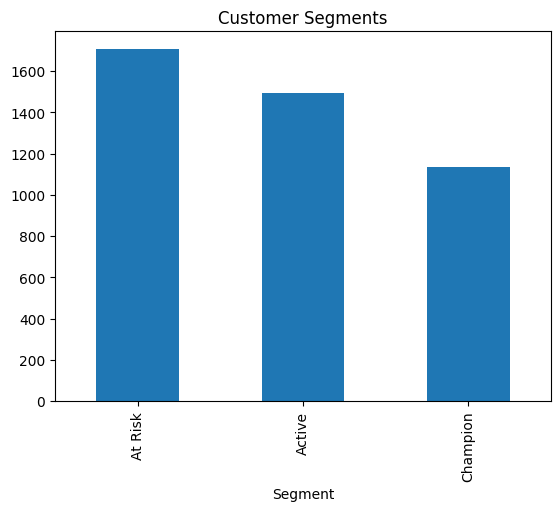

In [53]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Customer Segments')
plt.show()

RFM analysis was conducted to segment customers based on their purchasing behaviour. Recency measures how recently a customer made a purchase, Frequency reflects how often they purchase, and Monetary represents total spending.

Customers were scored using quantiles and grouped into segments, enabling identification of high-value and at-risk customers.

Customer segmentation based on RFM shows that the majority of customers fall into the “At Risk” category, indicating a large portion of customers have not purchased recently. A smaller group of customers are classified as “Active,” while “Champion” customers represent a minority but are likely to contribute significantly to revenue.

## Business Insights